# Dates — date-enrichment cascade and polity-of-citizenship age.

In [1]:
import re
import random

import numpy as np
import polars as pl
import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/humans_clean.duckdb'

pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

COLORS = {
    'cumulative_share': '#2171b5',
}

mpl.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   10,
})


## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)


## Date-source coverage table

For each date source: share of all individuals (col 1) and what fraction of those reach sub-year precision (col 2). Spans (places, citizenship polities) have no point-date precision and show `—`.

In [3]:
SPAN_MARKER = '—'

TOTAL_INDIVIDUALS = con.execute('SELECT COUNT(*) FROM individuals').fetchone()[0]

def count(sql):
    return con.execute(sql).fetchone()[0]

def subyear_share(count_sql, subyear_sql):
    n_with = count(count_sql)
    n_sub  = count(subyear_sql)
    note   = f'{n_sub / n_with * 100:.2f}%' if n_with else SPAN_MARKER
    return n_with, note

def fixed_note(count_sql, note):
    return count(count_sql), note

def span_source(count_sql):
    return count(count_sql), SPAN_MARKER

def cv_source():
    n_total = count("""
        SELECT COUNT(*) FROM individuals
        WHERE birthdate_from_CV IS NOT NULL OR deathdate_from_CV IS NOT NULL
    """)
    n_century = count("""
        SELECT COUNT(*) FROM individuals
        WHERE birthdate_from_CV LIKE '%51' OR deathdate_from_CV LIKE '%51'
    """)
    return n_total, f'{(1 - n_century / n_total) * 100:.2f}%'

sources = [
    ('Birth date — Wikidata property', *subyear_share(
        'SELECT COUNT(*) FROM individuals WHERE birthdate IS NOT NULL',
        'SELECT COUNT(*) FROM individuals WHERE birthdate IS NOT NULL AND birthdate_precision >= 10',
    )),
    ('Death date — Wikidata property', *subyear_share(
        'SELECT COUNT(*) FROM individuals WHERE deathdate IS NOT NULL',
        'SELECT COUNT(*) FROM individuals WHERE deathdate IS NOT NULL AND deathdate_precision >= 10',
    )),
    ('Floruit date — Wikidata property', *subyear_share(
        'SELECT COUNT(*) FROM individuals WHERE floruit_date IS NOT NULL',
        'SELECT COUNT(*) FROM individuals WHERE floruit_date IS NOT NULL AND floruit_precision >= 10',
    )),
    ('Birth date — description', *fixed_note(
        'SELECT COUNT(*) FROM individuals WHERE birthdate_in_description IS NOT NULL',
        '0%',
    )),
    ('Death date — description', *fixed_note(
        'SELECT COUNT(*) FROM individuals WHERE deathdate_in_description IS NOT NULL',
        '0%',
    )),
    ('Floruit date — description', *fixed_note(
        'SELECT COUNT(*) FROM individuals WHERE floruit_year_in_description IS NOT NULL',
        '0%',
    )),
    ('Description — century only (unspecified type)', *fixed_note(
        """SELECT COUNT(*) FROM individuals
           WHERE date_description IS NOT NULL
             AND birthdate_in_description IS NULL
             AND deathdate_in_description IS NULL
             AND floruit_year_in_description IS NULL""",
        '100%',
    )),
    ('Country of citizenship — dissolution', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys,
               UNNEST(string_split(individuals_keys.country_of_citizenship_ids, ';')) AS country(qid)
        JOIN   country_of_citizenship
          ON   country_of_citizenship.wikidata_id = TRIM(country.qid)
        WHERE  individuals_keys.country_of_citizenship_ids IS NOT NULL
          AND  country_of_citizenship.dissolved IS NOT NULL
    """)),
    ('Country of citizenship — inception', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys,
               UNNEST(string_split(individuals_keys.country_of_citizenship_ids, ';')) AS country(qid)
        JOIN   country_of_citizenship
          ON   country_of_citizenship.wikidata_id = TRIM(country.qid)
        WHERE  individuals_keys.country_of_citizenship_ids IS NOT NULL
          AND  country_of_citizenship.inception IS NOT NULL
    """)),
    ('Birthplace — inception', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys
        JOIN   places ON places.id = individuals_keys.birthcity_id
        WHERE  places.inception_date IS NOT NULL
    """)),
    ('Birthplace — dissolution', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys
        JOIN   places ON places.id = individuals_keys.birthcity_id
        WHERE  places.dissolution_date IS NOT NULL
    """)),
    ('Deathplace — inception', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys
        JOIN   places ON places.id = individuals_keys.deathcity_id
        WHERE  places.inception_date IS NOT NULL
    """)),
    ('Deathplace — dissolution', *span_source("""
        SELECT COUNT(DISTINCT individuals_keys.wikidata_id)
        FROM   individuals_keys
        JOIN   places ON places.id = individuals_keys.deathcity_id
        WHERE  places.dissolution_date IS NOT NULL
    """)),
    ('Cross-verified database', *cv_source()),
    ('Works — publication date', *subyear_share(
        'SELECT COUNT(DISTINCT individual_id) FROM works WHERE publication_date IS NOT NULL',
        'SELECT COUNT(DISTINCT individual_id) FROM works WHERE publication_date IS NOT NULL AND publication_precision >= 10',
    )),
    ('Works — inception date', *subyear_share(
        'SELECT COUNT(DISTINCT individual_id) FROM works WHERE inception_date IS NOT NULL',
        'SELECT COUNT(DISTINCT individual_id) FROM works WHERE inception_date IS NOT NULL AND inception_precision >= 10',
    )),
]

rows = [
    {
        'source':          label,
        'pct_individuals': f'{n_with / TOTAL_INDIVIDUALS * 100:.2f}%',
        'precision_note':  precision_note,
    }
    for label, n_with, precision_note in sources
]

n_any_date = count("""
    WITH all_dated AS (
      SELECT wikidata_id FROM individuals
      WHERE  birthdate IS NOT NULL OR deathdate IS NOT NULL OR floruit_date IS NOT NULL
         OR  birthdate_in_description IS NOT NULL OR deathdate_in_description IS NOT NULL
         OR  floruit_year_in_description IS NOT NULL OR dates_in_description IS NOT NULL
         OR  birthdate_from_CV IS NOT NULL OR deathdate_from_CV IS NOT NULL
      UNION
      SELECT individuals_keys.wikidata_id
      FROM   individuals_keys,
             UNNEST(string_split(individuals_keys.country_of_citizenship_ids, ';')) AS country(qid)
      JOIN   country_of_citizenship
        ON   country_of_citizenship.wikidata_id = TRIM(country.qid)
      WHERE  individuals_keys.country_of_citizenship_ids IS NOT NULL
        AND (country_of_citizenship.inception IS NOT NULL
             OR country_of_citizenship.dissolved IS NOT NULL)
      UNION
      SELECT individuals_keys.wikidata_id FROM individuals_keys
      JOIN   places ON places.id = individuals_keys.birthcity_id
      WHERE  places.inception_date IS NOT NULL OR places.dissolution_date IS NOT NULL
      UNION
      SELECT individuals_keys.wikidata_id FROM individuals_keys
      JOIN   places ON places.id = individuals_keys.deathcity_id
      WHERE  places.inception_date IS NOT NULL OR places.dissolution_date IS NOT NULL
      UNION
      SELECT individual_id AS wikidata_id FROM works
      WHERE  publication_date IS NOT NULL OR inception_date IS NOT NULL
    )
    SELECT COUNT(*) FROM all_dated
""")

n_year_precision = count("""
    WITH year_precision AS (
      SELECT wikidata_id FROM individuals
      WHERE (birthdate    IS NOT NULL AND birthdate_precision    >= 9)
         OR (deathdate    IS NOT NULL AND deathdate_precision    >= 9)
         OR (floruit_date IS NOT NULL AND floruit_precision      >= 9)
         OR  birthdate_in_description    IS NOT NULL
         OR  deathdate_in_description    IS NOT NULL
         OR  floruit_year_in_description IS NOT NULL
         OR (birthdate_from_CV IS NOT NULL AND birthdate_from_CV NOT LIKE '%51')
         OR (deathdate_from_CV IS NOT NULL AND deathdate_from_CV NOT LIKE '%51')
      UNION
      SELECT individual_id AS wikidata_id FROM works
      WHERE (publication_date IS NOT NULL AND publication_precision >= 9)
         OR (inception_date    IS NOT NULL AND inception_precision    >= 9)
    )
    SELECT COUNT(*) FROM year_precision
""")

rows.append({
    'source':          'TOTAL — at least one date',
    'pct_individuals': f'{n_any_date / TOTAL_INDIVIDUALS * 100:.2f}%',
    'precision_note':  f'{n_year_precision / n_any_date * 100:.2f}%',
})

date_source_coverage = pl.DataFrame(rows)
print(f'Total unique individuals: {TOTAL_INDIVIDUALS:,}')
print('shape:', date_source_coverage.shape)
date_source_coverage


Total unique individuals: 13,003,420
shape: (17, 3)


source,pct_individuals,precision_note
str,str,str
"""Birth date — Wikidata property""","""57.77%""","""62.77%"""
"""Death date — Wikidata property""","""27.48%""","""69.57%"""
"""Floruit date — Wikidata property""","""0.53%""","""2.04%"""
"""Birth date — description""","""15.81%""","""0%"""
"""Death date — description""","""11.51%""","""0%"""
"""Floruit date — description""","""10.70%""","""0%"""
"""Description — century only (unspecified type)""","""0.17%""","""100%"""
"""Country of citizenship — dissolution""","""7.72%""","""—"""
"""Country of citizenship — inception""","""42.78%""","""—"""


## Primary date flags from individuals  (original / description / works / cross-verified DB)

In [4]:
primary_flags = con.execute("""
    SELECT  wikidata_id,
            (birthdate IS NOT NULL OR deathdate IS NOT NULL OR floruit_date IS NOT NULL)
                AS has_original,
            (birthdate_in_description IS NOT NULL OR deathdate_in_description IS NOT NULL
             OR floruit_year_in_description IS NOT NULL OR dates_in_description IS NOT NULL)
                AS has_description,
            (works_period IS NOT NULL)
                AS has_works,
            (birthdate_from_CV IS NOT NULL OR deathdate_from_CV IS NOT NULL)
                AS has_cv
    FROM    individuals
""").pl()

print('shape:', primary_flags.shape)
primary_flags.head()


shape: (13003420, 5)


wikidata_id,has_original,has_description,has_works,has_cv
str,bool,bool,bool,bool
"""Q10000001""",true,true,false,false
"""Q1000002""",true,true,true,true
"""Q10000029""",false,false,false,false
"""Q1000005""",true,true,true,true
"""Q1000006""",true,false,true,true


## Individuals whose country of citizenship has an inception or dissolution date

In [5]:
country_dated_individuals = con.execute("""
    WITH
      country_pairs AS (
        SELECT  individuals_keys.wikidata_id,
                TRIM(country.qid) AS country_qid
        FROM    individuals_keys,
                UNNEST(string_split(individuals_keys.country_of_citizenship_ids, ';')) AS country(qid)
        WHERE   individuals_keys.country_of_citizenship_ids IS NOT NULL
      )
    SELECT DISTINCT
            country_pairs.wikidata_id
    FROM    country_pairs
    JOIN    country_of_citizenship
        ON  country_of_citizenship.wikidata_id = country_pairs.country_qid
    WHERE   country_of_citizenship.inception IS NOT NULL
       OR   country_of_citizenship.dissolved IS NOT NULL
""").pl()

print('shape:', country_dated_individuals.shape)
country_dated_individuals.head()


shape: (5565202, 1)


wikidata_id
str
"""Q109791466"""
"""Q109791544"""
"""Q109791588"""
"""Q109791607"""
"""Q109792307"""


## Individuals whose birth or death city has an inception or dissolution date

In [6]:
city_dated_individuals = con.execute("""
    WITH
      dated_cities AS (
        SELECT id FROM places
        WHERE inception_date IS NOT NULL OR dissolution_date IS NOT NULL
      ),
      birth_city_match AS (
        SELECT individuals_keys.wikidata_id
        FROM individuals_keys
        JOIN dated_cities ON dated_cities.id = individuals_keys.birthcity_id
      ),
      death_city_match AS (
        SELECT individuals_keys.wikidata_id
        FROM individuals_keys
        JOIN dated_cities ON dated_cities.id = individuals_keys.deathcity_id
      )
    SELECT DISTINCT wikidata_id FROM (
      SELECT wikidata_id FROM birth_city_match
      UNION ALL
      SELECT wikidata_id FROM death_city_match
    )
""").pl()

print('shape:', city_dated_individuals.shape)
city_dated_individuals.head()


shape: (2373128, 1)


wikidata_id
str
"""Q10380962"""
"""Q103821163"""
"""Q103821954"""
"""Q1038293"""
"""Q103829726"""


## Combined per-individual date flags

In [7]:
individual_date_flags = (
    primary_flags
    .join(country_dated_individuals.with_columns(pl.lit(True).alias('has_country_span')),
          on='wikidata_id', how='left')
    .join(city_dated_individuals.with_columns(pl.lit(True).alias('has_city_span')),
          on='wikidata_id', how='left')
    .with_columns(
        pl.col('has_country_span').fill_null(False),
        pl.col('has_city_span').fill_null(False),
    )
)

assert individual_date_flags.height == primary_flags.height, 'join changed row count'
print('shape:', individual_date_flags.shape)
individual_date_flags.head()


shape: (13003420, 7)


wikidata_id,has_original,has_description,has_works,has_cv,has_country_span,has_city_span
str,bool,bool,bool,bool,bool,bool
"""Q10000001""",true,true,false,false,true,true
"""Q1000002""",true,true,true,true,true,true
"""Q10000029""",false,false,false,false,true,false
"""Q1000005""",true,true,true,true,true,false
"""Q1000006""",true,false,true,true,true,true


## Recursive cascade  (each individual attributed to the first matching source)

In [8]:
ENRICHMENT_STEPS = [
    ('Originally (at least one date)',         'has_original'),
    ('From descriptions',                       'has_description'),
    ('From works (min/max dates)',              'has_works'),
    ('From the cross-verified database',        'has_cv'),
    ('From the country-of-citizenship span',    'has_country_span'),
    ('From the birth/death city span',          'has_city_span'),
]

total_individuals = individual_date_flags.height
already_covered = pl.Series('covered', [False] * total_individuals)
cascade_rows = []

for step_label, flag_column in ENRICHMENT_STEPS:
    flag = individual_date_flags[flag_column]
    newly_covered = flag & ~already_covered
    new_count = int(newly_covered.sum())
    already_covered = already_covered | flag
    cumulative_count = int(already_covered.sum())
    cascade_rows.append({
        'step':      step_label,
        'added':     new_count,
        'added_pct': new_count / total_individuals * 100,
        'cum_pct':   cumulative_count / total_individuals * 100,
    })

cascade = pl.DataFrame(cascade_rows)
print('total_individuals:', f'{total_individuals:,}')
print('shape:', cascade.shape)
cascade


total_individuals: 13,003,420
shape: (6, 4)


step,added,added_pct,cum_pct
str,i64,f64,f64
"""Originally (at least one date)""",7813121,60.085124,60.085124
"""From descriptions""",173209,1.332026,61.41715
"""From works (min/max dates)""",2166963,16.664562,78.081712
"""From the cross-verified database""",3105,0.023878,78.105591
"""From the country-of-citizenship span""",854499,6.57134,84.676931
"""From the birth/death city span""",17406,0.133857,84.810788


## Paper-ready markdown table

In [9]:
def fmt_pct(p):
    return '<0.1%' if 0 < p < 0.1 else f'{p:.2f}%'

print('| Method | Unique individuals dated | Cumulative coverage |')
print('|---|---:|---:|')
for row in cascade.iter_rows(named=True):
    print(f"| {row['step']} | +{fmt_pct(row['added_pct'])} | {row['cum_pct']:.2f}% |")
final_coverage = cascade[-1, 'cum_pct']
print(f'| **Total with date/period** | **{final_coverage:.2f}%** | **{final_coverage:.2f}%** |')


| Method | Unique individuals dated | Cumulative coverage |
|---|---:|---:|
| Originally (at least one date) | +60.09% | 60.09% |
| From descriptions | +1.33% | 61.42% |
| From works (min/max dates) | +16.66% | 78.08% |
| From the cross-verified database | +<0.1% | 78.11% |
| From the country-of-citizenship span | +6.57% | 84.68% |
| From the birth/death city span | +0.13% | 84.81% |
| **Total with date/period** | **84.81%** | **84.81%** |


## Country of citizenship table  (one row per polity, with raw inception/dissolved date strings)

In [10]:
country_polities = con.execute("""
    SELECT  wikidata_id,
            name_en,
            count       AS n_individuals,
            inception,
            dissolved
    FROM    country_of_citizenship
""").pl()

print('shape:', country_polities.shape)
country_polities.head()


shape: (4572, 5)


wikidata_id,name_en,n_individuals,inception,dissolved
str,str,i64,str,str
"""Q570740""","""Duchy of Legnica""",8,"""1248-01-01T00:00:00Z""","""1675-11-21T00:00:00Z"""
"""Q25272716""","""Maore sultanate""",2,"""1500-01-01T00:00:00Z""","""1841-04-25T00:00:00Z"""
"""Q284667""","""Electorate of Mainz""",22,"""0780-01-01T00:00:00Z""","""1803-01-01T00:00:00Z"""
"""Q3845757""","""Marquisate of Bosco""",1,null,null
"""Q1062546""","""Later Jin (1616-1636)""",15,"""1616-01-01T00:00:00Z""","""1636-01-01T00:00:00Z"""


## Parse polity dates  (earliest inception, latest dissolution, lifespan)

In [11]:
ISO_YEAR_PATTERN = re.compile(r'^(-?\d{1,4})-\d{2}-\d{2}T')

def parse_year_list(cell):
    if cell is None or cell == '':
        return []
    out = []
    for token in cell.split('|'):
        match = ISO_YEAR_PATTERN.match(token.strip())
        if match:
            out.append(int(match.group(1)))
    return out

def earliest_year(cell):
    years = parse_year_list(cell)
    return min(years) if years else None

def latest_year(cell):
    years = parse_year_list(cell)
    return max(years) if years else None

country_polities = country_polities.with_columns(
    pl.col('inception').map_elements(earliest_year, return_dtype=pl.Int64).alias('inception_year'),
    pl.col('dissolved').map_elements(latest_year,   return_dtype=pl.Int64).alias('dissolved_year'),
).with_columns(
    (pl.col('dissolved_year') - pl.col('inception_year')).alias('lifespan_years')
)

print('shape:', country_polities.shape)
country_polities.select(['name_en', 'n_individuals', 'inception_year', 'dissolved_year', 'lifespan_years']).head()


shape: (4572, 8)


name_en,n_individuals,inception_year,dissolved_year,lifespan_years
str,i64,i64,i64,i64
"""Duchy of Legnica""",8,1248,1675,427
"""Maore sultanate""",2,1500,1841,341
"""Electorate of Mainz""",22,780,1803,1023
"""Marquisate of Bosco""",1,null,null,null
"""Later Jin (1616-1636)""",15,1616,1636,20


## Polity age weighted by individuals  (modern inception → today / dissolution)

In [12]:
TODAY_YEAR = 2026

country_polities = country_polities.with_columns(
    pl.col('inception').map_elements(latest_year, return_dtype=pl.Int64).alias('modern_inception_year')
).with_columns(
    pl.when(pl.col('dissolved_year').is_not_null())
      .then(pl.col('dissolved_year') - pl.col('modern_inception_year'))
      .otherwise(TODAY_YEAR - pl.col('modern_inception_year'))
      .alias('polity_age')
)

aged_polities = country_polities.filter(pl.col('polity_age').is_not_null())
ages    = aged_polities['polity_age'].to_numpy().astype(float)
weights = aged_polities['n_individuals'].to_numpy().astype(float)

print(f'aged_polities: {aged_polities.height:,}  '
      f'({100 * aged_polities.height / country_polities.height:.1f}% of all)')
print(f'individuals covered: {int(weights.sum()):,}')
aged_polities.select(['name_en', 'n_individuals', 'modern_inception_year', 'polity_age']).sort('n_individuals', descending=True).head(10)


aged_polities: 2,779  (60.8% of all)
individuals covered: 6,028,684


name_en,n_individuals,modern_inception_year,polity_age
str,i64,i64,i64
"""United States""",659823,1784,242
"""France""",387185,1804,222
"""Germany""",325196,1949,77
"""Japan""",252340,1947,79
"""United Kingdom""",233021,1927,99
"""Spain""",175862,1978,48
"""Soviet Union""",173248,1922,69
"""Italy""",151615,1946,80
"""Canada""",140125,1867,159


## Fig 1 — Cumulative share of individuals by polity age

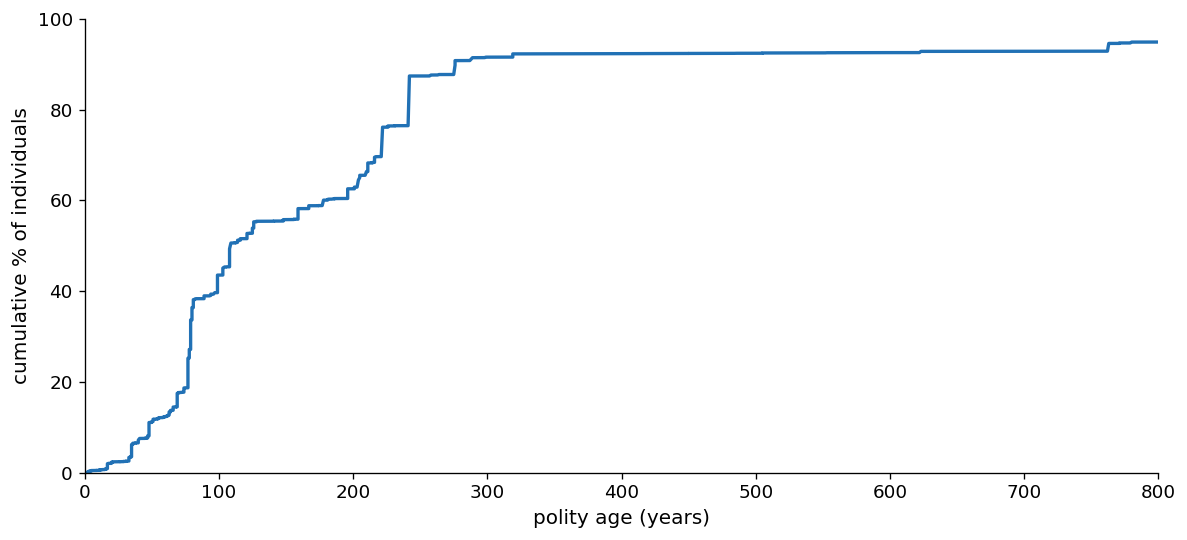

In [13]:
POLITY_AGE_X_MAX = 800

order = np.argsort(ages)
ages_sorted    = ages[order]
weights_sorted = weights[order]
cumulative_share = np.cumsum(weights_sorted) / weights_sorted.sum()

xs = np.concatenate([[0], ages_sorted,        [ages_sorted.max()]])
ys = np.concatenate([[0], cumulative_share,   [1.0]])

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(xs, 100 * ys, color=COLORS['cumulative_share'], lw=2)

ax.set_xlim(0, POLITY_AGE_X_MAX)
ax.set_ylim(0, 100)
ax.set_xlabel('polity age (years)')
ax.set_ylabel('cumulative % of individuals')
plt.tight_layout()
plt.show()


## Close

In [14]:
con.close()
